# NOTEBOOK MODELO

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import chi2_contingency
from itertools import combinations
from scipy.stats import f_oneway

import os
import re

from IPython.display import display, Markdown

import missingno as msno
import sys

from rapidfuzz import process, fuzz

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


from itertools import product

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_modelo = pd.read_csv(r'C:\Users\Nitropc\Documents\Github\TFM-Sesgos-en-el-sistema-judicial-de-EEUU-\00_Data\00_Processed\df_modelo.csv')

In [7]:
df_modelo.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age',
       'days_in_jail', 'priors_count', 'juv_priors_count', 'c_charge_degree',
       'maritalstatus'],
      dtype='object')

## Nuestro Modelo

In [8]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race']       #revisar una vez esté todo claro

In [9]:
lista_col_outliers = [
    'age',
    'priors_count',
    'juv_priors_count',
]

for col in lista_col_outliers:

    lower = df_modelo[col].quantile(0.01)
    upper = df_modelo[col].quantile(0.99)

    df_sin_outliers = df_modelo[
        (df_modelo[col] >= lower) &
        (df_modelo[col] <= upper)
    ]

In [14]:
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 69, stratify = y)

model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.5).astype(int)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})

print(coeficientes)

Matriz de confusión:
[[654  78]
 [272 157]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.71      0.89      0.79       732
           1       0.67      0.37      0.47       429

    accuracy                           0.70      1161
   macro avg       0.69      0.63      0.63      1161
weighted avg       0.69      0.70      0.67      1161

ROC AUC: 0.7247506591768887
           Variable  Coeficiente
0               sex    -0.413450
1               age    -0.042082
2      days_in_jail     0.003178
3      priors_count     0.143384
4  juv_priors_count     0.205664
5   c_charge_degree    -0.108215


Matriz de confusión:




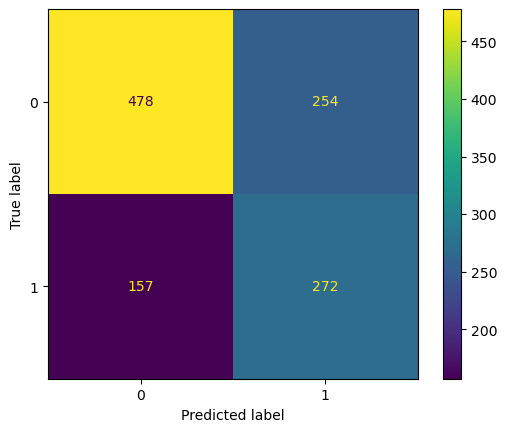

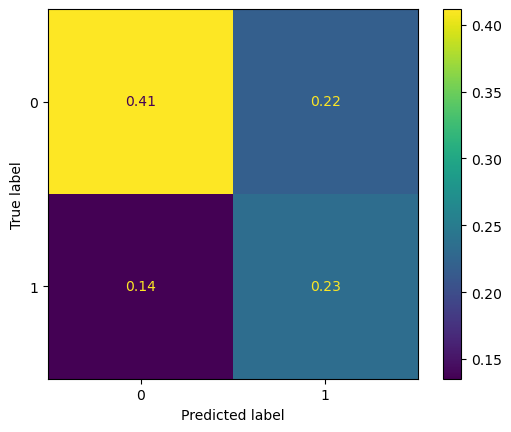

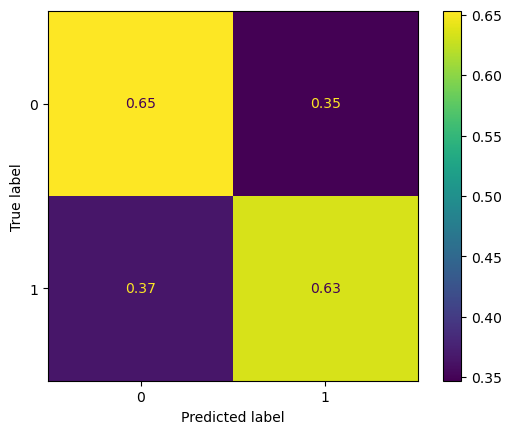



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.75      0.65      0.70       732
           1       0.52      0.63      0.57       429

    accuracy                           0.65      1161
   macro avg       0.63      0.64      0.63      1161
weighted avg       0.67      0.65      0.65      1161

ROC AUC: 0.7013833161374144


In [24]:
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

model = BaggingClassifier(
    estimator=LogisticRegression(penalty='l1', solver='liblinear'),
    n_estimators=10
)

model.fit(X, y)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.37).astype(int)


print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


In [ ]:
# Probar con priors_count en función de la edad (ej: 4 antecedentes en 4 años vs 10 antecedentes en 40 años)